In [1]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=0

env: CUDA_VISIBLE_DEVICES=0


In [3]:
import torch
import argparse
import asyncio
import datetime
import os, random
import numpy as np
import pandas as pd
from torch.utils.data import Subset
from load_data import load_nako
from torch.utils.data import DataLoader
# from time_distance.MAE import models_mae
# from lightning_helpers import MAELightning
from torchvision import transforms
from linear_probe_utils import predict_mae_transforms, change_lbls
from plotting_utils import plot_embeddings, create_legend
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from openTSNE import TSNE
from omegaconf import OmegaConf
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, accuracy_score, ConfusionMatrixDisplay
from multi_level_split.util import train_test_split as patient_id_split
from utils import linear_acc
from linear_probe_utils import NAKOBase, extract_embeddings
torch.set_float32_matmul_precision('medium')
random.seed(2024)

ENTITY = 'success_vera'
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle
import matplotlib as mpl
import nako

from nako import NakoDataset, get_nako_paths, IMAGE_TYPES, EYE_DISEASES
import json


In [4]:
config_file = '.secrets.yaml'
cfg = OmegaConf.load(config_file)
dataset_root = cfg['DATASETS']['NAKO']['mlcloud']
dataset_root

'/home/berens/bep973/ifeoma_home/data/NAKO'

## Identify eye disease

In [5]:
LABELS_FILE = os.path.join(dataset_root, 'NAKO_metadata','labels', 'labels.csv')
METADATA_FILE = f'{dataset_root}/NAKO_metadata/labels/metadata_translated.csv'

In [6]:
decoder = nako.FeatureDecoder(os.path.join(LABELS_FILE, METADATA_FILE))


In [14]:
labels_df = pd.read_csv(os.path.join(dataset_root, 'NAKO_metadata','labels', 'labels.csv'))
labels_df.head()

/tmp/ipykernel_2155795/1976496445.py:1: DtypeWarning: Columns (0: rt_rightnasal_3_date, 1: rt_rightcent_3_date, 2: rt_leftnasal_3_date, 3: rt_leftcent_3_date) have mixed types. Specify dtype option on import or set low_memory=False.
  labels_df = pd.read_csv(os.path.join(dataset_root, 'NAKO_metadata','labels', 'labels.csv'))


,ID,tgr_nako,tgr_nako_df100k,basis_sex,basis_age,basis_ageclass,basis_lvl,a_ethn1,a_ethn2,a_ses_mig_status,...,d_rtbf_lve_dia_calch,d_rtbf_lve_ghost,d_rtbf_lve_hemo_pvdi,d_rtbf_lve_hemo_pvsp,d_rtbf_lve_hpig_pv,d_rtbf_lve_vasc_shun,d_rtbf_lve_vasc_fibr,d_rtbf_lve_vasc_malf,unt365_status,basis_uort
0,100000,1,2,2,61,60,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81
1,100001,1,1,2,53,50,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,811
2,100002,1,2,1,42,40,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,12
3,100003,1,2,1,34,30,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,33
4,100004,1,2,2,41,40,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,23


In [17]:
feature_names = ['basis_sex', 'd_an_aug_1', 'd_an_aug_2', 'd_an_aug_3',
                  'd_an_metdm2c_2', 'd_an_metdm2c_1','d_an_met_1']
df = labels_df[feature_names].copy()

feature_name = feature_names[0]
mapping, label = decoder.decode(feature_name)
df, mapping = decoder.group_nans(feature_name, mapping, df)
df[feature_name] = df[feature_name].map(mapping)

In [11]:
df.head()

,basis_sex,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1
0,Female,2.0,2.0,2.0,NaN,NaN,2.0
1,Female,2.0,2.0,2.0,NaN,NaN,2.0
2,Male,2.0,2.0,2.0,NaN,NaN,2.0
3,Male,2.0,2.0,2.0,NaN,NaN,2.0
4,Female,2.0,2.0,2.0,NaN,NaN,2.0


In [12]:
df.shape

(48460, 7)

## Analyse Eye Disease

In [4]:
!pwd

/mnt/lustre/work/berens/bep973/leverage-data/leverage_data


In [5]:
root = '.'

In [6]:
disease_labels = {
'd_an_aug_1': 'cataract', 
'd_an_aug_2': 'glaucoma', 
'd_an_aug_3': 'MD',
'd_an_metdm2c_2': 'blindness', 
'd_an_metdm2c_1': 'retinopathy',
'd_an_met_1': 'diabetes_mellitus'
                    }

In [7]:
df  = pd.read_csv(os.path.join(root, 'datasets/NAKO/diseased_eyes.csv'))
df.rename(columns=disease_labels, inplace=True)
df.shape

(5102, 8)

In [8]:
# df.to_csv('/gpfs01/berens/user/inwabufo/leverage/leverage-data/metadata/nako_eye_disease.csv', index = False)

In [9]:
dict1 = {}
for col in df.columns[2:]:
    if col not in dict1.keys():
        dict1[col] = []
        dict1[col] =df[col].value_counts().to_dict()
dict1

{'cataract': {'No': 3039, 'Yes': 2042, 'Missing': 21},
 'glaucoma': {'No': 4102, 'Yes': 971, 'Missing': 29},
 'MD': {'No': 4627, 'Yes': 429, 'Missing': 46},
 'blindness': {'Missing': 2728, 'No': 2373, 'Yes': 1},
 'retinopathy': {'Missing': 2771, 'No': 2240, 'Yes': 91},
 'diabetes_mellitus': {'No': 2716, 'Yes': 2380, 'Missing': 6}}

In [10]:
k = pd.DataFrame(dict1).T.reset_index()
k
table = pd.pivot_table(
    k, values=['No', 'Yes', 'Missing'], index=["index"],  aggfunc="sum"
)
table
# Row-wise: what % of each condition's total is "Yes"
k['Yes_pct_row'] = k['Yes'] / k[['No', 'Yes', 'Missing']].sum(axis=1) * 100

# Column-wise: what % of the overall "Yes" total does each condition contribute
k['Yes_pct_col'] = k['Yes'] / k['Yes'].sum() * 100
k[['Yes_pct_row', 'Yes_pct_col']] = k[['Yes_pct_row', 'Yes_pct_col']].round(1)
k

,index,No,Yes,Missing,Yes_pct_row,Yes_pct_col
0,cataract,3039,2042,21,40.0,34.5
1,glaucoma,4102,971,29,19.0,16.4
2,MD,4627,429,46,8.4,7.3
3,blindness,2373,1,2728,0.0,0.0
4,retinopathy,2240,91,2771,1.8,1.5
5,diabetes_mellitus,2716,2380,6,46.6,40.2


## Load data

In [11]:
def change_lbls(dataset_, diseased_ids):
    for i, ids in enumerate(dataset_.ids):
        if ids in diseased_ids:
            dataset_.labels[i] = 1
        else:
            dataset_.labels[i] = 0

In [12]:
img_size = 224
batch_size = 64


all_data = load_nako(image_size =  img_size, 
                batch_size = batch_size, 
                label_name = None, 
                return_loader = False, 
                normalize = True, 
                return_all = True, 
                return_ids = False)
all_dataset_train, _, _, _, transforms_ = all_data
len(all_dataset_train)
diseased_ids = list(df['ID'])
change_lbls(all_dataset_train, diseased_ids)
all_dataset_train.labels = all_dataset_train.labels.astype(int)
print(np.unique(all_dataset_train.labels, return_counts = True))


Dataset  loaded with 122571 training samples, 15245 test samples, and 15318 validation samples.
returning all
returning all datasets
(array([0, 1]), array([139964,  13170]))


## Explore & Make Data

In [13]:
# start_time = datetime.datetime.now()
# start_time_fmt = start_time.strftime("%Y-%m-%d %H:%M:%S")

In [14]:
import json

In [15]:

x1 = len(os.listdir(f'{dataset_root}/images_lowres/224/rt_leftcentral'))
x2 = len(os.listdir(f'{dataset_root}/images_lowres/224/rt_leftnasal'))
x3 = len(os.listdir(f'{dataset_root}/images_lowres/224/rt_rightcentral'))
x4 = len(os.listdir(f'{dataset_root}/images_lowres/224/rt_rightnasal'))
print(x1, x2, x3, x4)
print(x1+ x2+ x3+ x4)


37158 35202 40248 40526
153134


In [16]:
print(dataset_root)

/home/berens/bep973/ifeoma_home/data/NAKO


In [17]:
splits_file = os.path.join(dataset_root, 'images_lowres', 'splits.json')
with open(splits_file, 'r') as f:
    splits = json.load(f)

In [18]:
mapping_df = pd.read_csv(os.path.join(dataset_root, 'images_lowres', 'mapping.csv'))
mapping_df.head()

,ID,rt_leftcentral,rt_leftnasal,rt_rightcentral,rt_rightnasal
0,100000,True,True,True,True
1,100001,True,True,True,True
2,100002,True,True,True,True
3,100003,True,True,True,True
4,100004,True,True,True,True


In [19]:
import numpy as np

cols = ['rt_leftcentral',	'rt_leftnasal',	'rt_rightcentral',	'rt_rightnasal']  # your 4 columns
rng = np.random.default_rng(seed=42)

def pick_random_true(row):
    true_cols = row.index[row].tolist()  # column names where value is True
    if not true_cols:
        return None  # handle rows with no True at all
    return rng.choice(true_cols)

mapping_df['selected_column'] = mapping_df[cols].apply(pick_random_true, axis=1)
mapping_df.head()

,ID,rt_leftcentral,rt_leftnasal,rt_rightcentral,rt_rightnasal,selected_column
0,100000,True,True,True,True,rt_leftcentral
1,100001,True,True,True,True,rt_rightnasal
2,100002,True,True,True,True,rt_rightcentral
3,100003,True,True,True,True,rt_leftnasal
4,100004,True,True,True,True,rt_leftnasal


In [20]:
disease_df = pd.read_csv('/home/berens/bep973/ifeoma_home/data/NAKO/NAKO_metadata/nako_eye_disease.csv')
disease_df.head()

,ID,basis_sex,cataract,glaucoma,MD,blindness,retinopathy,diabetes_mellitus
0,100049,Female,No,No,No,No,No,Yes
1,100069,Male,No,No,No,No,No,Yes
2,100082,Male,Yes,No,No,Missing,Missing,No
3,100091,Female,No,Yes,No,Missing,Missing,No
4,100094,Female,Yes,No,No,Missing,Missing,No


In [21]:
m = pd.merge(mapping_df, disease_df, how = 'left', on = 'ID')
m['cataract'].value_counts(dropna = False)

cataract
NaN        40895
No          2656
Yes         1681
Missing       15
Name: count, dtype: int64

In [22]:
disease_cols = ['cataract', 'glaucoma', 'MD', 'blindness', 'retinopathy',	'diabetes_mellitus']
m[disease_cols] = m[disease_cols].fillna('Unknown')
m['cataract'].value_counts(dropna = False)

cataract
Unknown    40895
No          2656
Yes         1681
Missing       15
Name: count, dtype: int64

In [23]:
dict1 = {}
for col in m.columns[2:]:
    if col not in dict1.keys():
        dict1[col] = []
        dict1[col] =m[col].value_counts().to_dict()
dict1

{'rt_leftnasal': {True: 35202, False: 10045},
 'rt_rightcentral': {True: 40248, False: 4999},
 'rt_rightnasal': {True: 40526, False: 4721},
 'selected_column': {np.str_('rt_rightnasal'): 12593,
  np.str_('rt_rightcentral'): 12256,
  np.str_('rt_leftcentral'): 10698,
  np.str_('rt_leftnasal'): 9700},
 'basis_sex': {'Female': 2197, 'Male': 2155},
 'cataract': {'Unknown': 40895, 'No': 2656, 'Yes': 1681, 'Missing': 15},
 'glaucoma': {'Unknown': 40895, 'No': 3486, 'Yes': 845, 'Missing': 21},
 'MD': {'Unknown': 40895, 'No': 3934, 'Yes': 382, 'Missing': 36},
 'blindness': {'Unknown': 40895, 'Missing': 2344, 'No': 2008},
 'retinopathy': {'Unknown': 40895, 'Missing': 2375, 'No': 1911, 'Yes': 66},
 'diabetes_mellitus': {'Unknown': 40895,
  'No': 2333,
  'Yes': 2014,
  'Missing': 5}}

In [24]:
k = pd.DataFrame(dict1).T.reset_index()
k

,index,True,False,rt_rightnasal,rt_rightcentral,rt_leftcentral,rt_leftnasal,Female,Male,Unknown,No,Yes,Missing
0,rt_leftnasal,35202.0,10045.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,rt_rightcentral,40248.0,4999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,rt_rightnasal,40526.0,4721.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,selected_column,NaN,NaN,12593.0,12256.0,10698.0,9700.0,NaN,NaN,NaN,NaN,NaN,NaN
4,basis_sex,NaN,NaN,NaN,NaN,NaN,NaN,2197.0,2155.0,NaN,NaN,NaN,NaN
5,cataract,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40895.0,2656.0,1681.0,15.0
6,glaucoma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40895.0,3486.0,845.0,21.0
7,MD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40895.0,3934.0,382.0,36.0
8,blindness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40895.0,2008.0,NaN,2344.0
9,retinopathy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40895.0,1911.0,66.0,2375.0


In [25]:
table = pd.pivot_table(
    k, values=['No', 'Yes', 'Missing', 'Unknown'], index=["index"],  aggfunc="sum"
)
table

,Missing,No,Unknown,Yes
index,,,,
MD,36.0,3934.0,40895.0,382.0
basis_sex,0.0,0.0,0.0,0.0
blindness,2344.0,2008.0,40895.0,0.0
cataract,15.0,2656.0,40895.0,1681.0
diabetes_mellitus,5.0,2333.0,40895.0,2014.0
glaucoma,21.0,3486.0,40895.0,845.0
retinopathy,2375.0,1911.0,40895.0,66.0
rt_leftnasal,0.0,0.0,0.0,0.0
rt_rightcentral,0.0,0.0,0.0,0.0


In [26]:
# Row-wise: what % of each condition's total is "Yes"
k['Yes_pct_row'] = k['Yes'] / k[['No', 'Yes', 'Missing', 'Unknown']].sum(axis=1) * 100

# Column-wise: what % of the overall "Yes" total does each condition contribute
k['Yes_pct_col'] = k['Yes'] / k['Yes'].sum() * 100
k[['Yes_pct_row', 'Yes_pct_col']] = k[['Yes_pct_row', 'Yes_pct_col']].round(1)
k

,index,True,False,rt_rightnasal,rt_rightcentral,rt_leftcentral,rt_leftnasal,Female,Male,Unknown,No,Yes,Missing,Yes_pct_row,Yes_pct_col
0,rt_leftnasal,35202.0,10045.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,rt_rightcentral,40248.0,4999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,rt_rightnasal,40526.0,4721.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,selected_column,NaN,NaN,12593.0,12256.0,10698.0,9700.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,basis_sex,NaN,NaN,NaN,NaN,NaN,NaN,2197.0,2155.0,NaN,NaN,NaN,NaN,NaN,NaN
5,cataract,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40895.0,2656.0,1681.0,15.0,3.7,33.7
6,glaucoma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40895.0,3486.0,845.0,21.0,1.9,16.9
7,MD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40895.0,3934.0,382.0,36.0,0.8,7.7
8,blindness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40895.0,2008.0,NaN,2344.0,NaN,NaN
9,retinopathy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40895.0,1911.0,66.0,2375.0,0.1,1.3


In [27]:
import numpy as np

indices = np.arange(len(cols))  # [0, 1, 2, ...] matching position of each column in `cols`
mapping_df['all_cols'] = mapping_df[cols].astype(int).values.tolist()
mapping_df.head(3)
mapping_df['all_cols_weighted'] = mapping_df['all_cols'].apply(
    lambda lst: [v * (i+1) for i, v in enumerate(lst)]
)
mapping_df.tail(3)

,ID,rt_leftcentral,rt_leftnasal,rt_rightcentral,rt_rightnasal,selected_column,all_cols,all_cols_weighted
45244,148460,True,True,True,True,rt_leftcentral,"[1, 1, 1, 1]","[1, 2, 3, 4]"
45245,148461,True,True,True,True,rt_leftcentral,"[1, 1, 1, 1]","[1, 2, 3, 4]"
45246,148462,True,True,True,True,rt_rightnasal,"[1, 1, 1, 1]","[1, 2, 3, 4]"


In [28]:
mapping_df['theres_zero'] = mapping_df['all_cols_weighted'].apply(lambda x: 0 in x)
mapping_df['theres_zero'].value_counts()

theres_zero
False    28318
True     16929
Name: count, dtype: int64

In [29]:
mapping_df[mapping_df['theres_zero']==True]

,ID,rt_leftcentral,rt_leftnasal,rt_rightcentral,rt_rightnasal,selected_column,all_cols,all_cols_weighted,theres_zero
6,100006,True,True,False,True,rt_leftcentral,"[1, 1, 0, 1]","[1, 2, 0, 4]",True
12,100012,False,True,True,False,rt_rightcentral,"[0, 1, 1, 0]","[0, 2, 3, 0]",True
14,100014,True,True,True,False,rt_rightcentral,"[1, 1, 1, 0]","[1, 2, 3, 0]",True
15,100015,True,True,True,False,rt_rightcentral,"[1, 1, 1, 0]","[1, 2, 3, 0]",True
17,100018,False,False,False,True,rt_rightnasal,"[0, 0, 0, 1]","[0, 0, 0, 4]",True
...,...,...,...,...,...,...,...,...,...
45228,148442,True,False,True,True,rt_rightcentral,"[1, 0, 1, 1]","[1, 0, 3, 4]",True
45232,148448,True,False,True,True,rt_rightnasal,"[1, 0, 1, 1]","[1, 0, 3, 4]",True
45238,148454,False,False,True,True,rt_rightnasal,"[0, 0, 1, 1]","[0, 0, 3, 4]",True
45240,148456,False,False,True,True,rt_rightnasal,"[0, 0, 1, 1]","[0, 0, 3, 4]",True


In [30]:
mapping_df.shape

(45247, 9)

In [31]:
import numpy as np
rng = np.random.default_rng(seed=42)

def pick_random_nonzero_col(weighted_list, cols):
    nonzero_indices = [i for i, v in enumerate(weighted_list) if v != 0]
    if not nonzero_indices:
        return None  # no nonzero values in this row
    chosen_idx = rng.choice(nonzero_indices)
    return cols[chosen_idx]

mapping_df['selected_column'] = mapping_df['all_cols_weighted'].apply(
    lambda x: pick_random_nonzero_col(x, cols)
)

In [32]:
mapping_df['selected_column'].value_counts(dropna = False)

selected_column
rt_rightnasal      12593
rt_rightcentral    12256
rt_leftcentral     10698
rt_leftnasal        9700
Name: count, dtype: int64

In [33]:
import numpy as np
rng = np.random.default_rng(seed=42)

def pick_random_nonzero_col(weighted_list, cols):
    nonzero_indices = [i for i, v in enumerate(weighted_list) if v != 0]

    if not nonzero_indices:
        return None  # no nonzero values in this row
    else:
        return (len(nonzero_indices))

mapping_df['count_col'] = mapping_df['all_cols_weighted'].apply(
    lambda x: pick_random_nonzero_col(x, cols)
)

In [34]:
mapping_df['count_col'].value_counts(dropna = False)

count_col
4    28318
3     8975
2     4983
1     2971
Name: count, dtype: int64

In [35]:
sum(list(mapping_df['count_col'].value_counts(dropna = False)))

45247

In [36]:
vc = mapping_df['count_col'].value_counts()

total = int(np.sum(np.array(vc.index) * np.array(vc.values)))
total

153134

In [37]:
mapping_df[mapping_df['theres_zero']==True]

,ID,rt_leftcentral,rt_leftnasal,rt_rightcentral,rt_rightnasal,selected_column,all_cols,all_cols_weighted,theres_zero,count_col
6,100006,True,True,False,True,rt_leftcentral,"[1, 1, 0, 1]","[1, 2, 0, 4]",True,3
12,100012,False,True,True,False,rt_rightcentral,"[0, 1, 1, 0]","[0, 2, 3, 0]",True,2
14,100014,True,True,True,False,rt_rightcentral,"[1, 1, 1, 0]","[1, 2, 3, 0]",True,3
15,100015,True,True,True,False,rt_rightcentral,"[1, 1, 1, 0]","[1, 2, 3, 0]",True,3
17,100018,False,False,False,True,rt_rightnasal,"[0, 0, 0, 1]","[0, 0, 0, 4]",True,1
...,...,...,...,...,...,...,...,...,...,...
45228,148442,True,False,True,True,rt_rightcentral,"[1, 0, 1, 1]","[1, 0, 3, 4]",True,3
45232,148448,True,False,True,True,rt_rightnasal,"[1, 0, 1, 1]","[1, 0, 3, 4]",True,3
45238,148454,False,False,True,True,rt_rightnasal,"[0, 0, 1, 1]","[0, 0, 3, 4]",True,2
45240,148456,False,False,True,True,rt_rightnasal,"[0, 0, 1, 1]","[0, 0, 3, 4]",True,2


In [39]:
dataset_root

'/home/berens/bep973/ifeoma_home/data/NAKO'

In [40]:
labels_df = pd.read_csv(os.path.join(dataset_root, 'NAKO_metadata','labels', 'labels.csv'))
labels_df.head()

/tmp/ipykernel_1723500/1976496445.py:1: DtypeWarning: Columns (0: rt_rightnasal_3_date, 1: rt_rightcent_3_date, 2: rt_leftnasal_3_date, 3: rt_leftcent_3_date) have mixed types. Specify dtype option on import or set low_memory=False.
  labels_df = pd.read_csv(os.path.join(dataset_root, 'NAKO_metadata','labels', 'labels.csv'))


,ID,tgr_nako,tgr_nako_df100k,basis_sex,basis_age,basis_ageclass,basis_lvl,a_ethn1,a_ethn2,a_ses_mig_status,...,d_rtbf_lve_dia_calch,d_rtbf_lve_ghost,d_rtbf_lve_hemo_pvdi,d_rtbf_lve_hemo_pvsp,d_rtbf_lve_hpig_pv,d_rtbf_lve_vasc_shun,d_rtbf_lve_vasc_fibr,d_rtbf_lve_vasc_malf,unt365_status,basis_uort
0,100000,1,2,2,61,60,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81
1,100001,1,1,2,53,50,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,811
2,100002,1,2,1,42,40,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,12
3,100003,1,2,1,34,30,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,33
4,100004,1,2,2,41,40,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,23


In [43]:
LABELS_FILE = os.path.join(dataset_root, 'NAKO_metadata','labels', 'labels.csv')
METADATA_FILE = f'{dataset_root}/NAKO_metadata/labels/metadata_translated.csv'

In [44]:
decoder = nako.FeatureDecoder(os.path.join(LABELS_FILE, METADATA_FILE))


In [45]:
colors = sns.color_palette('pastel', 10)
colors = cycle([mpl.colors.rgb2hex(c) for c in colors])

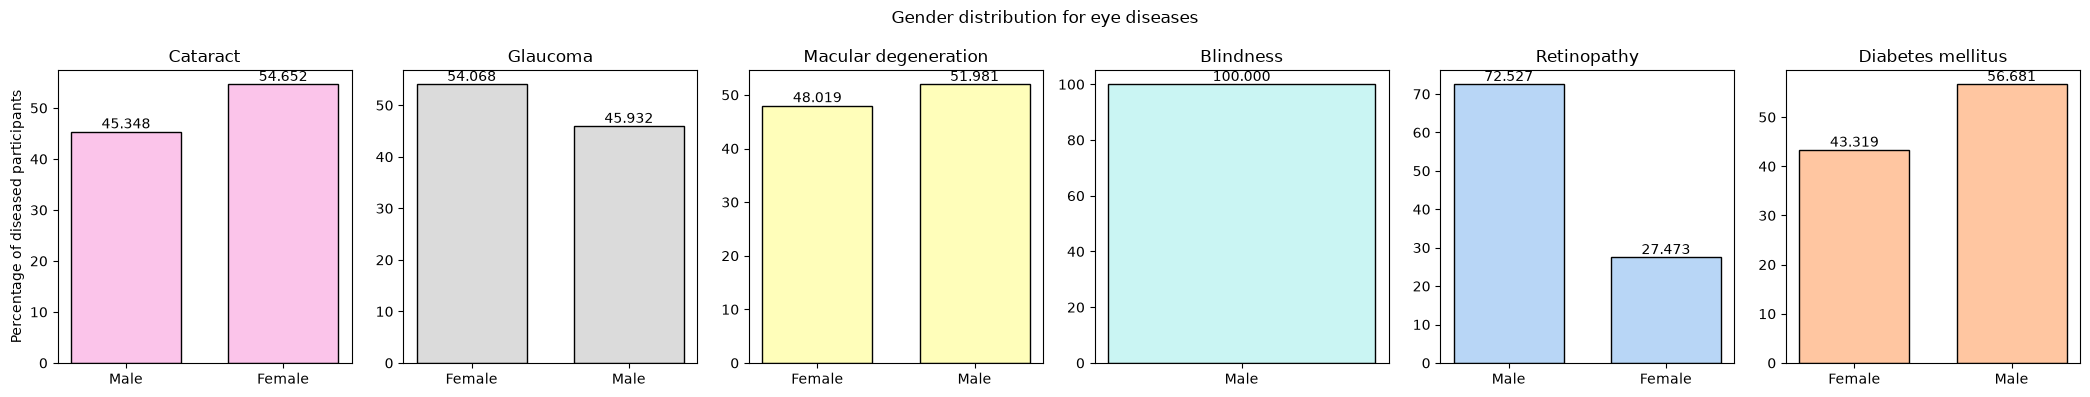

In [47]:
feature_names = [ 'basis_sex'] + EYE_DISEASES
df = labels_df[feature_names].copy()

feature_name = feature_names[0]
mapping, label = decoder.decode(feature_name)
df, mapping = decoder.group_nans(feature_name, mapping, df)
df[feature_name] = df[feature_name].map(mapping)

fig, ax = plt.subplots(1, 6, figsize=(21, 4))

for i, feature_name in enumerate(feature_names[1:]):
    mapping, label = decoder.decode(feature_name)
    df, mapping = decoder.group_nans(feature_name, mapping, df)
    df[feature_name] = df[feature_name].map(mapping)
    # print(df[feature_name].value_counts(dropna = False))
    df_filtered = df[df[feature_name] == 'Yes']
    sns.histplot(x='basis_sex', data=df_filtered, stat='percent', shrink=0.7, color=next(colors), ax=ax[i])

    ax[i].bar_label(ax[i].containers[0], fmt='%.3f')
    ax[i].set_title(label.capitalize())
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    
ax[0].set_ylabel('Percentage of diseased participants')
fig.suptitle('Gender distribution for eye diseases')
plt.tight_layout()

In [48]:
labels_df['d_an_aug_1'].value_counts(dropna = False)

d_an_aug_1
2.0       46297
1.0        2042
9999.0      100
NaN          18
8888.0        3
Name: count, dtype: int64

In [49]:
labels_df['d_an_aug_2'].value_counts(dropna = False)

d_an_aug_2
2.0       47338
1.0         971
9999.0      130
NaN          18
8888.0        3
Name: count, dtype: int64

In [50]:
labels_df['d_an_aug_3'].value_counts(dropna = False)

d_an_aug_3
2.0       47870
1.0         429
9999.0      140
NaN          18
8888.0        3
Name: count, dtype: int64

In [51]:
labels_df['d_an_metdm2c_2'].value_counts(dropna = False)

d_an_metdm2c_2
NaN       46080
2.0        2373
8888.0        5
1.0           1
9999.0        1
Name: count, dtype: int64

In [52]:
labels_df['d_an_metdm2c_1'].value_counts(dropna = False)

d_an_metdm2c_1
NaN       46080
2.0        2240
1.0          91
9999.0       44
8888.0        5
Name: count, dtype: int64

In [53]:
labels_df['d_an_met_1'].value_counts(dropna = False)

d_an_met_1
2.0       46016
1.0        2380
9999.0       51
NaN          10
8888.0        3
Name: count, dtype: int64

In [54]:
labels_df[['ID']+ EYE_DISEASES]

,ID,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1
0,100000,2.0,2.0,2.0,NaN,NaN,2.0
1,100001,2.0,2.0,2.0,NaN,NaN,2.0
2,100002,2.0,2.0,2.0,NaN,NaN,2.0
3,100003,2.0,2.0,2.0,NaN,NaN,2.0
4,100004,2.0,2.0,2.0,NaN,NaN,2.0
...,...,...,...,...,...,...,...
48455,148458,2.0,2.0,2.0,NaN,NaN,2.0
48456,148459,2.0,2.0,2.0,2.0,2.0,1.0
48457,148460,2.0,2.0,2.0,NaN,NaN,2.0
48458,148461,2.0,2.0,2.0,NaN,NaN,2.0


In [55]:
labels_df[EYE_DISEASES] = labels_df[EYE_DISEASES].fillna(100).astype(int)


In [56]:
has_1_or_2 = labels_df[EYE_DISEASES].isin([1, 2]).any(axis=1)
labels_df['all_unknown'] = (~has_1_or_2).astype(int)
labels_df['all_unknown'].value_counts(dropna = False)

/tmp/ipykernel_1723500/3113968343.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  labels_df['all_unknown'] = (~has_1_or_2).astype(int)


all_unknown
0    48449
1       11
Name: count, dtype: int64

In [57]:
print(labels_df.shape)
labels_df = labels_df[labels_df['all_unknown'] == 0]
print(labels_df.shape)


(48460, 549)
(48449, 549)


In [58]:
labels_df['any_eye_disease'] = (labels_df[EYE_DISEASES] == 1).any(axis=1).astype(int)
labels_df['any_eye_disease'].value_counts(dropna = False)

/tmp/ipykernel_1723500/2215720965.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  labels_df['any_eye_disease'] = (labels_df[EYE_DISEASES] == 1).any(axis=1).astype(int)


any_eye_disease
0    43347
1     5102
Name: count, dtype: int64

In [59]:
labels_df.head()

,ID,tgr_nako,tgr_nako_df100k,basis_sex,basis_age,basis_ageclass,basis_lvl,a_ethn1,a_ethn2,a_ses_mig_status,...,d_rtbf_lve_hemo_pvdi,d_rtbf_lve_hemo_pvsp,d_rtbf_lve_hpig_pv,d_rtbf_lve_vasc_shun,d_rtbf_lve_vasc_fibr,d_rtbf_lve_vasc_malf,unt365_status,basis_uort,all_unknown,any_eye_disease
0,100000,1,2,2,61,60,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81,0,0
1,100001,1,1,2,53,50,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,811,0,0
2,100002,1,2,1,42,40,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,10.0,12,0,0
3,100003,1,2,1,34,30,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,10.0,33,0,0
4,100004,1,2,2,41,40,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,10.0,23,0,0


In [60]:
labels_df.shape, mapping_df.shape

((48449, 550), (45247, 10))

In [61]:
48449-45247

3202

In [62]:
len(set(list(labels_df['ID'])).intersection(set(list(mapping_df['ID']))))

45237

In [63]:
len(set(list(labels_df['ID'])).difference(set(list(mapping_df['ID']))))

3212

In [64]:
len(set(list(mapping_df['ID'])).difference(set(list(labels_df['ID']))))

10

In [65]:
df_master = mapping_df.merge(labels_df, on = 'ID', how = 'left')
print(df_master.shape)
df_master.tail()

(45247, 559)


,ID,rt_leftcentral,rt_leftnasal,rt_rightcentral,rt_rightnasal,selected_column,all_cols,all_cols_weighted,theres_zero,count_col,...,d_rtbf_lve_hemo_pvdi,d_rtbf_lve_hemo_pvsp,d_rtbf_lve_hpig_pv,d_rtbf_lve_vasc_shun,d_rtbf_lve_vasc_fibr,d_rtbf_lve_vasc_malf,unt365_status,basis_uort,all_unknown,any_eye_disease
45242,148458,True,True,True,True,rt_rightcentral,"[1, 1, 1, 1]","[1, 2, 3, 4]",False,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.0,0.0,0.0
45243,148459,True,False,True,True,rt_rightnasal,"[1, 0, 1, 1]","[1, 0, 3, 4]",True,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.0,0.0,1.0
45244,148460,True,True,True,True,rt_leftcentral,"[1, 1, 1, 1]","[1, 2, 3, 4]",False,4,...,NaN,NaN,NaN,NaN,NaN,NaN,10.0,21.0,0.0,0.0
45245,148461,True,True,True,True,rt_leftcentral,"[1, 1, 1, 1]","[1, 2, 3, 4]",False,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,0.0,0.0
45246,148462,True,True,True,True,rt_rightnasal,"[1, 1, 1, 1]","[1, 2, 3, 4]",False,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.0,0.0,0.0


In [66]:
df_classify = df_master[['ID', 'selected_column', 'basis_sex', 'basis_uort', 'any_eye_disease', 'all_unknown']+EYE_DISEASES]
print(df_classify.shape)
df_classify.head()

(45247, 12)


,ID,selected_column,basis_sex,basis_uort,any_eye_disease,all_unknown,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1
0,100000,rt_leftcentral,2.0,81.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0
1,100001,rt_rightnasal,2.0,811.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0
2,100002,rt_rightcentral,1.0,12.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0
3,100003,rt_leftnasal,1.0,33.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0
4,100004,rt_leftnasal,2.0,23.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0


In [67]:
df_classify['any_eye_disease'].value_counts(dropna = False)

any_eye_disease
0.0    40885
1.0     4352
NaN       10
Name: count, dtype: int64

In [68]:
40885+4352

45237

In [69]:
print(df_classify.shape)
df_classify = df_classify.dropna(subset=['any_eye_disease'])
print(df_classify.shape)


(45247, 12)
(45237, 12)


In [70]:
df_classify['df_classify'] = df_classify['any_eye_disease'].apply(lambda x: int(x))

In [71]:
df_classify['any_eye_disease'].value_counts(dropna = False)

any_eye_disease
0.0    40885
1.0     4352
Name: count, dtype: int64

In [72]:
df_classify.rename(columns={'selected_column': 'img_path'}, inplace = True)

In [73]:
df_classify.head()

,ID,img_path,basis_sex,basis_uort,any_eye_disease,all_unknown,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1,df_classify
0,100000,rt_leftcentral,2.0,81.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
1,100001,rt_rightnasal,2.0,811.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
2,100002,rt_rightcentral,1.0,12.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
3,100003,rt_leftnasal,1.0,33.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
4,100004,rt_leftnasal,2.0,23.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0


In [74]:
len(set(list(df_classify['ID'])))

45237

In [75]:
df_one = df_classify[df_classify['any_eye_disease'] ==1]
print(df_one.shape)

(4352, 13)


In [76]:
df_zero_all = df_classify[df_classify['any_eye_disease'] ==0]
print(df_zero_all.shape)

(40885, 13)


In [77]:
10000-4352

5648

In [78]:
df_zeros = df_zero_all.sample(n=5648, random_state = 42)
df_zeros.shape


(5648, 13)

In [79]:
df_zeros

,ID,img_path,basis_sex,basis_uort,any_eye_disease,all_unknown,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1,df_classify
4131,104410,rt_leftcentral,2.0,71.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
40455,143322,rt_leftcentral,1.0,53.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
34863,137328,rt_leftnasal,2.0,11.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
13069,113982,rt_rightnasal,2.0,53.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
22804,124416,rt_rightcentral,1.0,11.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4037,104306,rt_rightcentral,1.0,11.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
38104,140779,rt_leftnasal,1.0,23.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
35045,137523,rt_rightnasal,1.0,81.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
26264,128128,rt_rightnasal,1.0,11.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0


In [80]:
df_classify_new = pd.concat((df_one, df_zeros))
print(df_classify_new.shape)
df_classify_new.head()

(10000, 13)


,ID,img_path,basis_sex,basis_uort,any_eye_disease,all_unknown,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1,df_classify
45,100049,rt_rightnasal,2.0,32.0,1.0,0.0,2.0,2.0,2.0,2.0,2.0,1.0,1
64,100069,rt_rightcentral,1.0,21.0,1.0,0.0,2.0,2.0,2.0,2.0,2.0,1.0,1
77,100082,rt_leftcentral,1.0,31.0,1.0,0.0,1.0,2.0,2.0,100.0,100.0,2.0,1
86,100091,rt_rightnasal,2.0,32.0,1.0,0.0,2.0,1.0,2.0,100.0,100.0,2.0,1
89,100095,rt_rightnasal,2.0,41.0,1.0,0.0,2.0,2.0,2.0,2.0,2.0,1.0,1


In [81]:
# Source - https://stackoverflow.com/a/34879805
# Posted by Kris, modified by community. See post 'Timeline' for change history
# Retrieved 2026-07-20, License - CC BY-SA 4.0

df_classify_new = df_classify_new.sample(frac=1, random_state = 42)


In [ ]:
dataset_dir_root = 'metadata'

In [ ]:
# df_classify_new.to_csv(f'{dataset_dir_root}/df_classify.csv', index = False)

In [ ]:
# df_classify.to_csv(f'{dataset_dir_root}/df_classify_main.csv', index = False)

## Linear Probe Test

In [ ]:
from load_models import get_encoder
from torch.utils.data import Dataset
from PIL import Image

In [ ]:
img_size =224
ssl_method = ''
dataset_name ='nako'
device ='cuda'
comment =''
group_name ='TMI'
task =None
project =''
batch_size =512
mask_ratio =0.5
testrun =False
use_scheduler =False
lr =5e-4
weight_decay =0.05
weights_path =None
compile = True

In [ ]:
nako_mean=[0.419, 0.209, 0.122]
nako_std = [0.280, 0.164, 0.113]

nako_transform_train = transforms.Compose([

        transforms.RandomResizedCrop(224,  scale=(0.2, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean = nako_mean, 
                            std = nako_std)
        ])
nako_transform_val = transforms.Compose([
        transforms.Resize(256, interpolation=3),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean = nako_mean, 
                            std = nako_std)
        ])

In [ ]:
image_size = 224
return_ids = True
contrastive = False
augment_train = nako_transform_train
label_name = EYE_DISEASES 
image_dir  = get_nako_paths(dataset='590', img_res=image_size)


In [ ]:
dataset_dir_root = 'metadata'

In [ ]:
!ls /gpfs01/berens/data/data/medical_imaging/NAKO/nako_decrypted

images	images_lowres  labels  README.md


In [ ]:
classify_metadata_df = pd.read_csv(f'{dataset_dir_root}/df_classify.csv')
classify_metadata_df.head()

,ID,img_path,basis_sex,basis_uort,any_eye_disease,all_unknown,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1,df_classify
0,142903,rt_rightcentral,1.0,53.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
1,146588,rt_rightcentral,1.0,22.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
2,119767,rt_leftnasal,2.0,51.0,1.0,0.0,1.0,2.0,2.0,100.0,100.0,2.0,1
3,124664,rt_leftnasal,1.0,21.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
4,127301,rt_rightnasal,2.0,21.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0


In [ ]:
classify_metadata_df["index"] = range(classify_metadata_df.shape[0])
classify_metadata_df.tail(2)

,ID,img_path,basis_sex,basis_uort,any_eye_disease,all_unknown,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1,df_classify,index
9998,109388,rt_rightnasal,2.0,21.0,1.0,0.0,1.0,1.0,2.0,2.0,1.0,1.0,1,9998
9999,123844,rt_leftcentral,2.0,32.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0,9999


In [ ]:
print(classify_metadata_df[classify_metadata_df['img_path'].isna()])

Empty DataFrame
Columns: [ID, img_path, basis_sex, basis_uort, any_eye_disease, all_unknown, d_an_aug_1, d_an_aug_2, d_an_aug_3, d_an_metdm2c_2, d_an_metdm2c_1, d_an_met_1, df_classify, index]
Index: []


In [ ]:
# image_dir = '/home/berens/bep973/ifeoma_home/data/NAKO/images_lowres/224'
image_dir = '/gpfs01/berens/data/data/medical_imaging/NAKO/nako_decrypted/images_lowres/224'
dataset_train_all = NAKOBase(image_dir,
                             f'{dataset_dir_root}/df_classify.csv',
                             transform=nako_transform_train)

train_loader_all = DataLoader(dataset_train_all, batch_size = batch_size, shuffle = False)

In [ ]:
print(len(dataset_train_all))


10000


In [ ]:
weights_name = 'simclr_scratch'
weights_path =  cfg['MODEL']['CIN'][weights_name]
weights_path

'/gpfs01/berens/user/inwabufo/survcnn_skeleton/survival_on_embedding/checkpoints/ssl_checkpoints/model_ckpt/arc_resnet18_modified_TMI_simclr_RC_randrot_HF_JI_NR_200_256_2025-09-07 18:03:20/checkpoint/model.pt'

In [ ]:
encoder, in_features, weights_path_returned, backbone_model_str = get_encoder(weights_path, device, 
                                                                             img_size=img_size,)

in simclr
initial model str resnet18_modified_TMI_simclr_RC_randrot_HF_JI_NR_200_256
updated model_str resnet18_modified
model_str resnet18_modified


In [ ]:
for p in encoder.parameters():
    p.requires_grad = False

In [ ]:
# testrun = True

In [ ]:
features = extract_embeddings(encoder, train_loader_all, device, testrun = testrun)


In [ ]:
!ls /gpfs01/berens/data/data/medical_imaging/NAKO/nako_decrypted/images_lowres

128  224  224_flipped  32  512	512_raw  mapping.csv  README.md  splits.json


In [ ]:

backbone_feat, label1, ids_, paths_ = features
print(backbone_feat.shape, label1.shape, ids_.shape, np.unique(label1, return_counts=True))

(10000, 512) (10000,) (10000,) (array([0, 1], dtype=uint8), array([5648, 4352]))


In [ ]:
#-----------------------------------Linear Probing---------------------------------------------#

acc, auc = linear_acc(X = backbone_feat, y = label1, id = ids_, 
                       stratify_col='label' )
print(f"acc {acc} auc {auc}")
print("---- \n computing tsne \n ---")


pca = PCA(n_components=100) 
H_pca = pca.fit_transform(backbone_feat) 
Y = TSNE(random_state=2000).fit(H_pca)

n unique labels 2
y train count (array([0, 1], dtype=uint8), array([4518, 3482]))
y test count (array([0, 1], dtype=uint8), array([1130,  870]))
X train shape (8000, 512) Y_train shape (8000,) X_tests shape (2000, 512) Y_test shape (2000,)
acc 62.69 auc 62.69
---- 
 computing tsne 
 ---
